# Stage 1.5 Quick EDA and Data Completeness Report
This notebook performs a quick Exploratory Data Analysis (EDA) under Stage 1.5.

### Objectives
1. **Load Stage 1.5 Outputs & Raw Data**: Read `master_image_inventory.csv`, image/numeric coverage crosscheck CSVs, daily fruit hardness measurements, and environmental sensor readings.
2. **Replicate Stage 1.5 EDA Metrics**: Generate summaries and figures for file types, dimensions, file size distributions, brightness levels, and RGB channel distributions.
3. **Data Completeness Analysis ("Destination Check")**:
   - Determine whether all collected frames have their corresponding daily hardness and environmental readings (images mapping to numeric destination).
   - Check if sensor logs and daily hardness measurements have matching webcam frames (numeric readings mapping to image destination).
   - Identify gaps and analyze temporal overlap to pinpoint hardware downtime or data capture issues.
4. **Temporal Variation Visualizations**: Plot temperature, humidity, firmness, and image visual characteristics (RGB, brightness, file size) over the 12-day experimental period.

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path

# Set plotting style for premium, consistent aesthetics
plt.style.use('ggplot')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 120
})

# Define paths relative to the project root
PROJECT_ROOT = Path("..") # Since the notebook is in 'notebooks/', we move up one level
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"

print("Setup complete. Project root:", PROJECT_ROOT.resolve())

Setup complete. Project root: D:\GW_UNIVERSITY\AIS\Fruit_shell_life\Env\UOG_AIS_Fruit_V2\Strawberry-RUL-prediction


In [ ]:
# Paths to files
master_csv_path = DATA_DIR / "02_processed/stage_1_5/full/master_image_inventory.csv"
image_coverage_csv_path = DATA_DIR / "02_processed/stage_1_5/full/image_numeric_coverage.csv"
numeric_coverage_csv_path = DATA_DIR / "02_processed/stage_1_5/full/numeric_image_coverage.csv"
raw_hardness_csv_path = DATA_DIR / "01_raw/avocado/hardness/hardness.csv"
raw_env_csv_path = DATA_DIR / "01_raw/avocado/th10s_readings.csv"

# Load datasets
df_master = pd.read_csv(master_csv_path)
df_img_cov = pd.read_csv(image_coverage_csv_path)
df_num_cov = pd.read_csv(numeric_coverage_csv_path)
df_hardness = pd.read_csv(raw_hardness_csv_path)
df_env = pd.read_csv(raw_env_csv_path)

print(f"Loaded master image inventory: {df_master.shape[0]} rows, {df_master.shape[1]} columns")
print(f"Loaded image-numeric coverage: {df_img_cov.shape[0]} rows")
print(f"Loaded numeric-image coverage: {df_num_cov.shape[0]} rows")
print(f"Loaded raw daily hardness: {df_hardness.shape[0]} rows")
print(f"Loaded raw env readings (th10s): {df_env.shape[0]} rows")

Loaded master image inventory: 1027 rows, 33 columns
Loaded image-numeric coverage: 1027 rows
Loaded numeric-image coverage: 1038 rows
Loaded raw daily hardness: 12 rows
Loaded raw env readings (th10s): 1026 rows


## 1. Stage 1.5 Core EDA Methods
Here we reconstruct the foundational technical property summaries and distributions specified in the Stage 1.5 plan.

In [ ]:
print("=== File extension counts ===")
print(df_master['extension'].value_counts())
print("\n=== Readable vs Unreadable Images ===")
print(df_master['is_readable'].value_counts())
print("\n=== Image Dimensions ===")
readable_df = df_master[df_master['is_readable'] == True]
print(readable_df.groupby(['width', 'height']).size().reset_index(name='count'))

=== File extension counts ===
extension
.jpg    1027
Name: count, dtype: int64

=== Readable vs Unreadable Images ===
is_readable
True    1027
Name: count, dtype: int64

=== Image Dimensions ===
   width  height  count
0   1920    1080   1027


C:\Users\DELL\AppData\Local\Temp\ipykernel_36560\751696844.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(rgb_data, labels=['Mean R', 'Mean G', 'Mean B'], patch_artist=True,


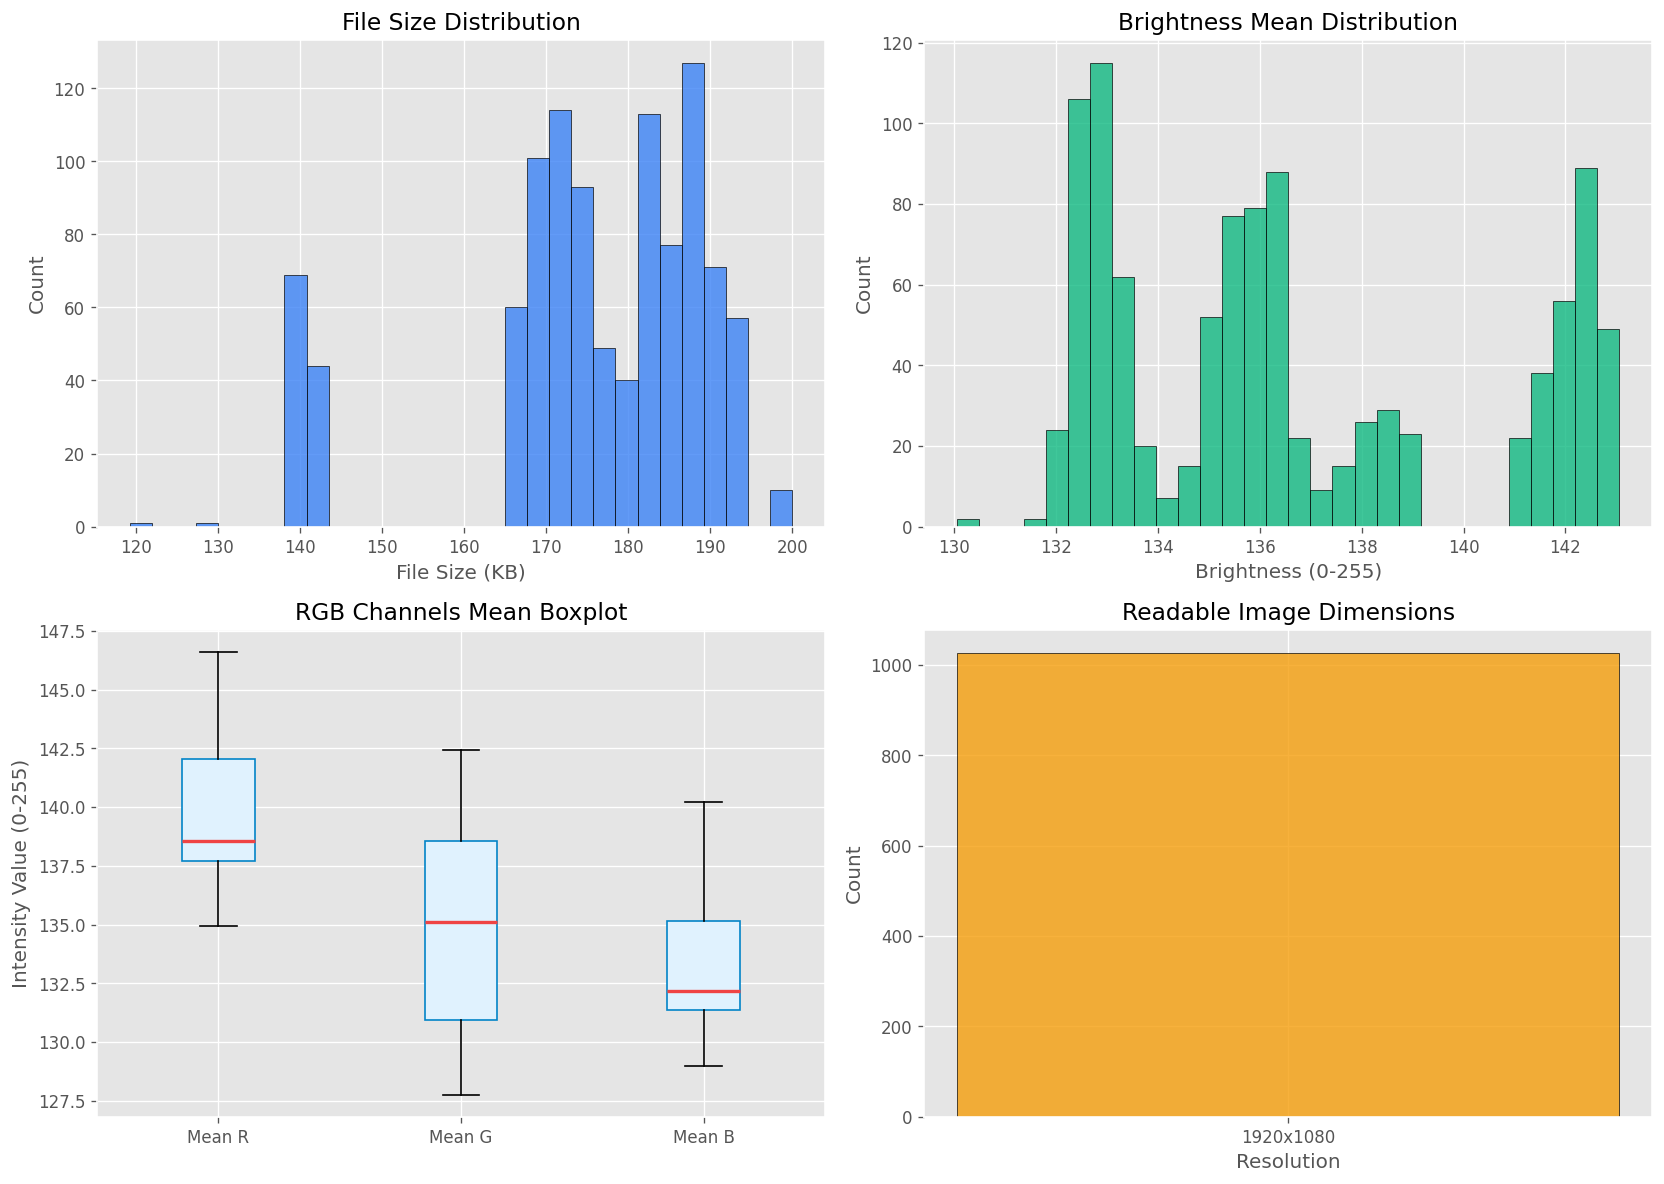

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. File size distribution
axes[0, 0].hist(readable_df['file_size_bytes'] / 1024, bins=30, color='#3b82f6', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('File Size Distribution')
axes[0, 0].set_xlabel('File Size (KB)')
axes[0, 0].set_ylabel('Count')

# 2. Brightness mean distribution
axes[0, 1].hist(readable_df['brightness_mean'], bins=30, color='#10b981', edgecolor='black', alpha=0.8)
axes[0, 1].set_title('Brightness Mean Distribution')
axes[0, 1].set_xlabel('Brightness (0-255)')
axes[0, 1].set_ylabel('Count')

# 3. RGB Mean distributions
rgb_data = [readable_df['mean_r'], readable_df['mean_g'], readable_df['mean_b']]
axes[1, 0].boxplot(rgb_data, labels=['Mean R', 'Mean G', 'Mean B'], patch_artist=True,
                  boxprops=dict(facecolor='#e0f2fe', color='#0284c7'),
                  medianprops=dict(color='#ef4444', linewidth=2))
axes[1, 0].set_title('RGB Channels Mean Boxplot')
axes[1, 0].set_ylabel('Intensity Value (0-255)')

# 4. Image dimensions distribution
dim_labels = (readable_df['width'].astype(str) + "x" + readable_df['height'].astype(str)).value_counts()
axes[1, 1].bar(dim_labels.index, dim_labels.values, color='#f59e0b', width=0.4, edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Readable Image Dimensions')
axes[1, 1].set_xlabel('Resolution')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 2. Data Completeness & Destination Analysis
To answer the core questions:
- **Do all raw image points have matching numeric values (firmness and environment readings)?**
- **Do all numeric values have their target destination (i.e. are there images corresponding to the logged sensors and daily firmness)?**

This section evaluates the alignment of datasets.

In [ ]:
# Analyze df_img_cov which matches each image with numeric databases
total_images = len(df_img_cov)
images_with_ts = df_img_cov['image_timestamp_key'].notna().sum()
images_without_ts = df_img_cov['image_timestamp_key'].isna().sum()

images_with_hardness = df_img_cov['has_hardness_date_record'].sum()
images_with_env = df_img_cov['has_environment_timestamp_record'].sum()

print("=== Image-Side Coverage & Completeness ===")
print(f"Total Discovered Images: {total_images}")
print(f"Images with parsed timestamp: {images_with_ts} ({images_with_ts/total_images*100:.2f}%)")
print(f"Images without parsed timestamp: {images_without_ts} ({images_without_ts/total_images*100:.2f}%)")
print(f"Images with daily hardness record: {images_with_hardness} ({images_with_hardness/total_images*100:.2f}%)")
print(f"Images with environmental sensor record: {images_with_env} ({images_with_env/total_images*100:.2f}%)")

# Let's inspect the files that failed timestamp parsing
failed_parsing = df_img_cov[df_img_cov['image_timestamp_key'].isna()]
if not failed_parsing.empty:
    print("\nFiles failing timestamp parsing (first 5 rows):")
    print(failed_parsing[['filename', 'relative_path', 'timestamp_parse_error']].head(5))

=== Image-Side Coverage & Completeness ===
Total Discovered Images: 1027
Images with parsed timestamp: 1026 (99.90%)
Images without parsed timestamp: 1 (0.10%)
Images with daily hardness record: 1026 (99.90%)
Images with environmental sensor record: 1026 (99.90%)

Files failing timestamp parsing (first 5 rows):
      filename                             relative_path  \
0  mock_id.jpg  data/01_raw/avocado/hardness/mock_id.jpg   

                           timestamp_parse_error  
0  filename does not match image timestamp regex  


In [ ]:
# Analyze df_num_cov which matches each numeric record with image database
total_hardness_dates = df_num_cov[df_num_cov['numeric_source'] == 'hardness'].shape[0]
hardness_with_images = df_num_cov[(df_num_cov['numeric_source'] == 'hardness') & (df_num_cov['has_matching_image'] == True)].shape[0]

total_env_timestamps = df_num_cov[df_num_cov['numeric_source'] == 'environment'].shape[0]
env_with_images = df_num_cov[(df_num_cov['numeric_source'] == 'environment') & (df_num_cov['has_matching_image'] == True)].shape[0]

print("=== Numeric-Side Coverage & Destination Completeness ===")
print(f"Total Daily Hardness Records: {total_hardness_dates}")
print(f"Hardness records with matching images: {hardness_with_images} ({hardness_with_images/total_hardness_dates*100:.2f}%)")
print(f"Hardness records missing matching images: {total_hardness_dates - hardness_with_images}")

print(f"\nTotal Environmental Sensor Logs (th10s): {total_env_timestamps}")
print(f"Sensor logs with matching images: {env_with_images} ({env_with_images/total_env_timestamps*100:.2f}%)")
print(f"Sensor logs missing matching images: {total_env_timestamps - env_with_images}")

=== Numeric-Side Coverage & Destination Completeness ===
Total Daily Hardness Records: 12
Hardness records with matching images: 12 (100.00%)
Hardness records missing matching images: 0

Total Environmental Sensor Logs (th10s): 1026
Sensor logs with matching images: 1026 (100.00%)
Sensor logs missing matching images: 0


### Analysis of Alignment Gaps (Time Delta Analysis)
Since environmental sensors might record at slightly different times compared to image capture, we will calculate the time delta between each image and its nearest environmental log to see if they align well.

=== Time delta distribution between images and nearest env readings (minutes) ===
count    1026.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: time_delta_min, dtype: float64


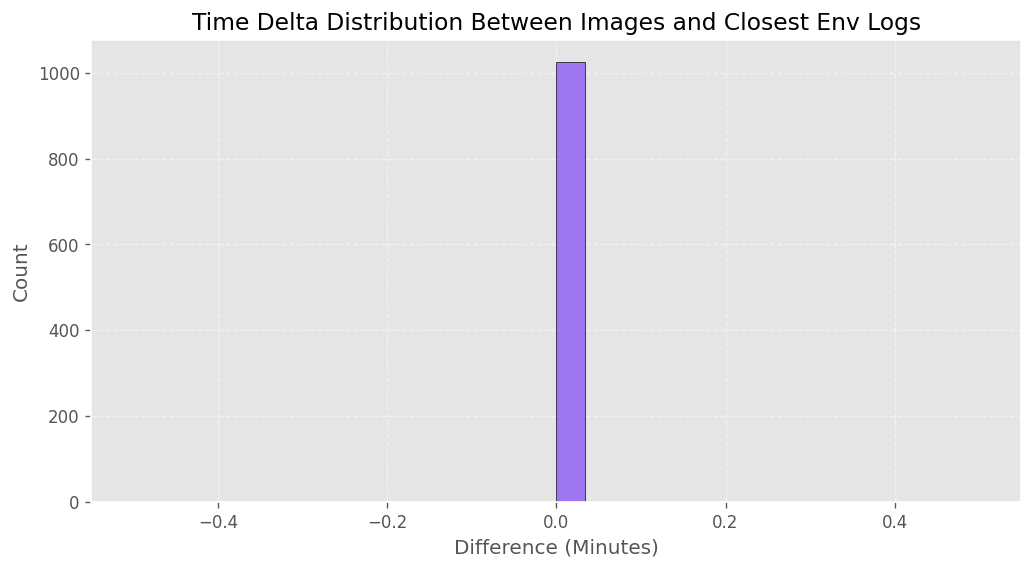

In [ ]:
# Helper to convert environment timestamps to datetime objects (ignoring tz for comparison)
df_env_parsed = df_env.copy()
df_env_parsed['datetime'] = pd.to_datetime(df_env_parsed['timestamp'].str[:19])

# Helper to convert master image timestamps to datetime
df_master_parsed = df_master.dropna(subset=['parsed_sample_id']).copy()
# Extract date and time from filename like webcam_2026-06-14_20-30-44
df_master_parsed['datetime_str'] = df_master_parsed['filename'].str.extract(r'webcam_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})')
df_master_parsed = df_master_parsed.dropna(subset=['datetime_str'])
df_master_parsed['datetime'] = pd.to_datetime(df_master_parsed['datetime_str'], format='%Y-%m-%d_%H-%M-%S')

# Sort both datasets by datetime for merge_asof
df_master_parsed = df_master_parsed.sort_values('datetime')
df_env_parsed = df_env_parsed.sort_values('datetime')

# Find nearest environmental reading for each image
merged_nearest = pd.merge_asof(
    df_master_parsed,
    df_env_parsed,
    on='datetime',
    direction='nearest',
    suffixes=('_img', '_env')
)

# Calculate difference in minutes
merged_nearest['time_delta_min'] = (merged_nearest['datetime'] - merged_nearest['timestamp'].apply(lambda x: pd.to_datetime(x[:19]))).abs().dt.total_seconds() / 60.0

print("=== Time delta distribution between images and nearest env readings (minutes) ===")
print(merged_nearest['time_delta_min'].describe())

# Plot the distribution of time deltas
plt.figure(figsize=(10, 5))
plt.hist(merged_nearest['time_delta_min'], bins=30, color='#8b5cf6', edgecolor='black', alpha=0.8)
plt.title('Time Delta Distribution Between Images and Closest Env Logs')
plt.xlabel('Difference (Minutes)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

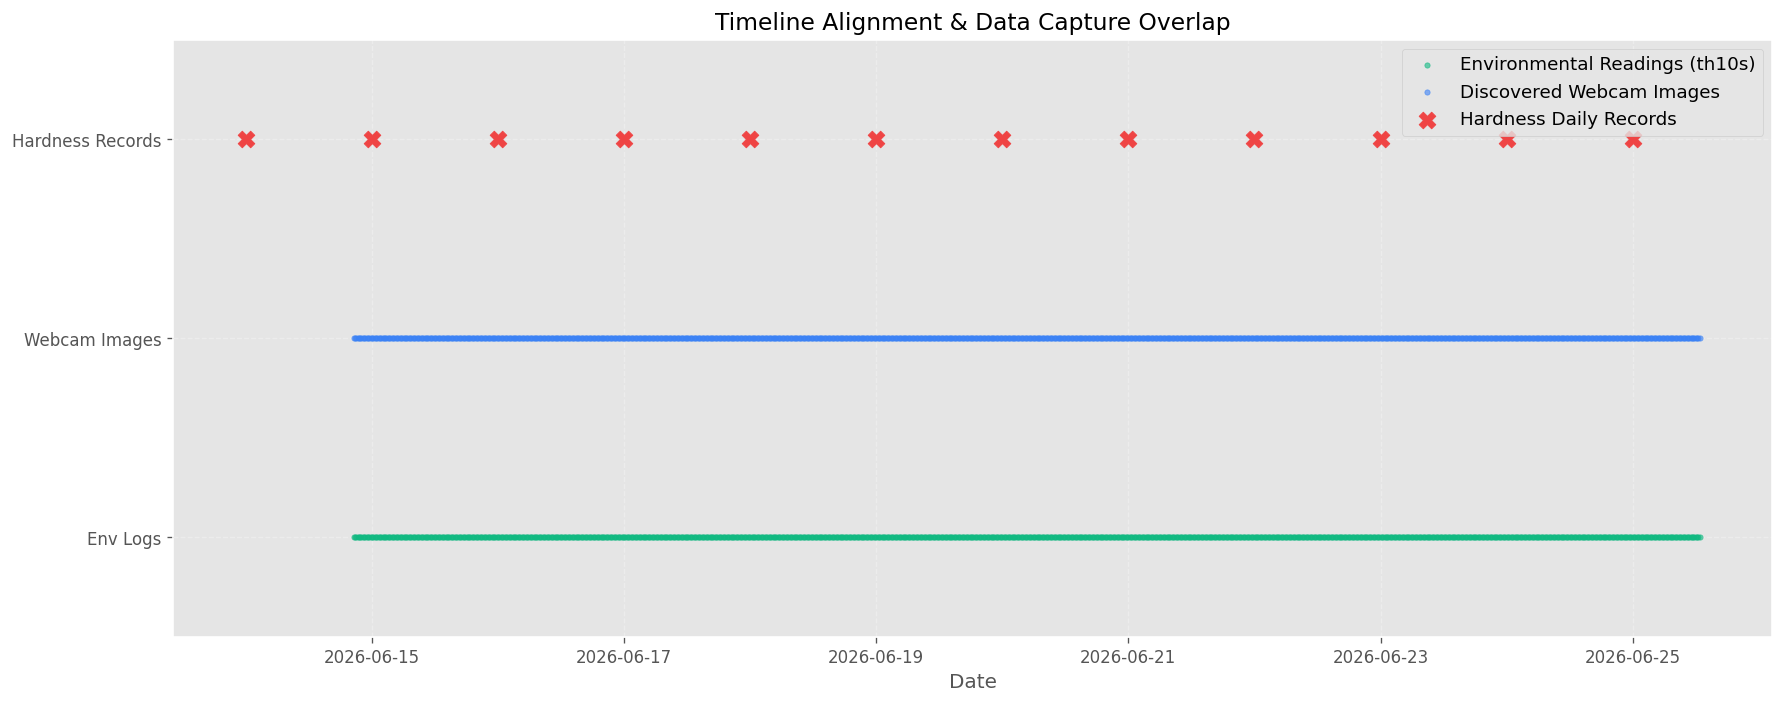

In [ ]:
# Plot Timeline showing sensor presence vs image presence
plt.figure(figsize=(15, 6))

# Plot env readings as small dots along the timeline
plt.scatter(df_env_parsed['datetime'], np.zeros(len(df_env_parsed)) + 1, 
            color='#10b981', s=10, alpha=0.6, label='Environmental Readings (th10s)')

# Plot images as small vertical lines along the timeline
plt.scatter(df_master_parsed['datetime'], np.zeros(len(df_master_parsed)) + 2, 
            color='#3b82f6', s=10, alpha=0.6, label='Discovered Webcam Images')

# Plot hardness dates
df_hardness_parsed = df_hardness.copy()
df_hardness_parsed['datetime'] = pd.to_datetime(df_hardness_parsed['time'])
plt.scatter(df_hardness_parsed['datetime'], np.zeros(len(df_hardness_parsed)) + 3, 
            color='#ef4444', s=100, marker='X', label='Hardness Daily Records')

plt.yticks([1, 2, 3], ['Env Logs', 'Webcam Images', 'Hardness Records'])
plt.ylim(0.5, 3.5)
plt.title('Timeline Alignment & Data Capture Overlap')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 3. Temporal Variation Visualizations
This section visualizes how visual properties (color channels, brightness, file sizes) and numeric measurements (temperature, humidity, hardness) change over time.

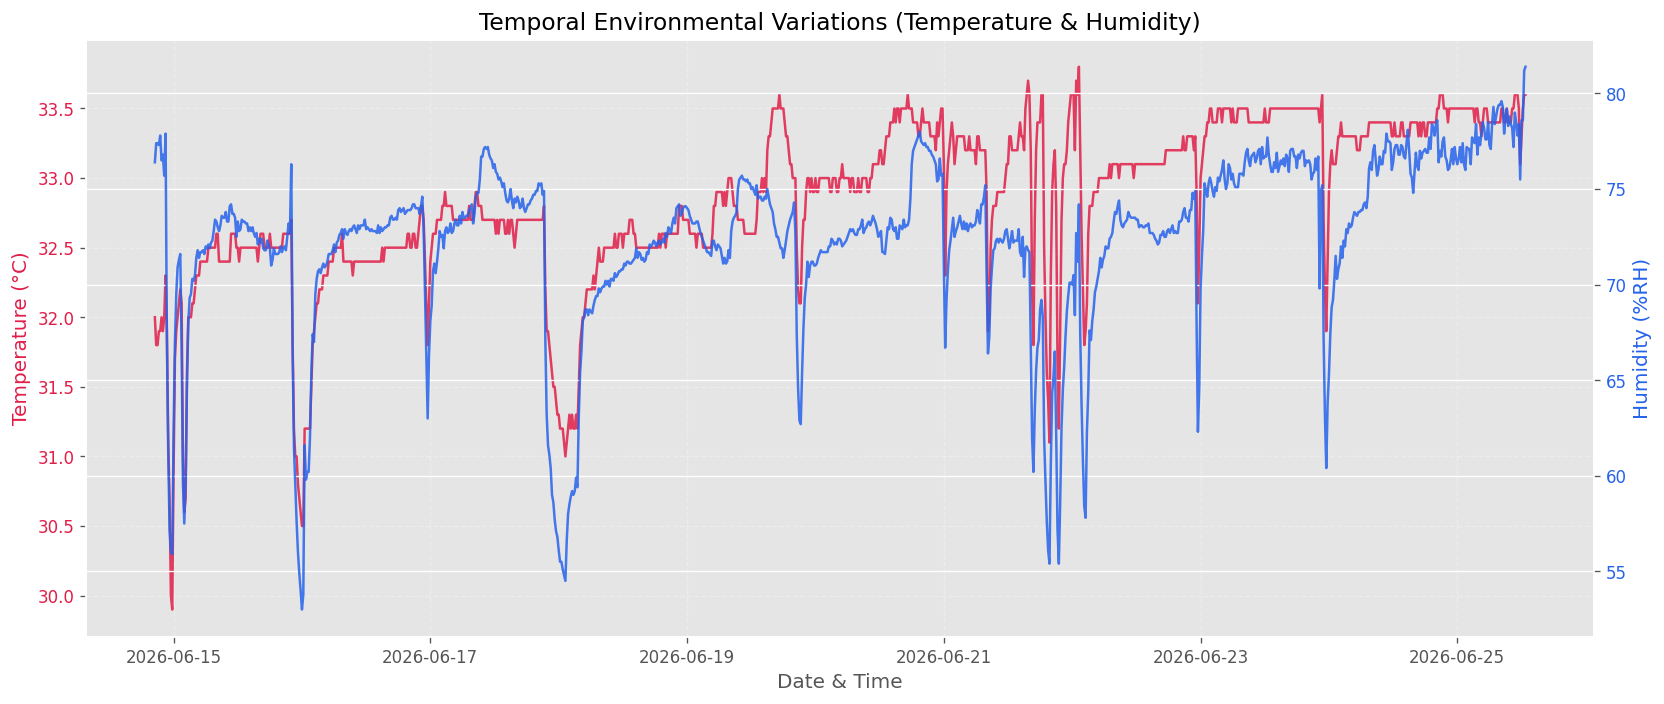

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot temperature
color = '#e11d48'
ax1.set_xlabel('Date & Time')
ax1.set_ylabel('Temperature (°C)', color=color)
ax1.plot(df_env_parsed['datetime'], df_env_parsed['temperature_c'], color=color, linewidth=1.5, alpha=0.85, label='Temperature')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.3)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  
color = '#2563eb'
ax2.set_ylabel('Humidity (%RH)', color=color)
ax2.plot(df_env_parsed['datetime'], df_env_parsed['humidity_rh'], color=color, linewidth=1.5, alpha=0.85, label='Humidity')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Temporal Environmental Variations (Temperature & Humidity)')
fig.tight_layout()
plt.show()

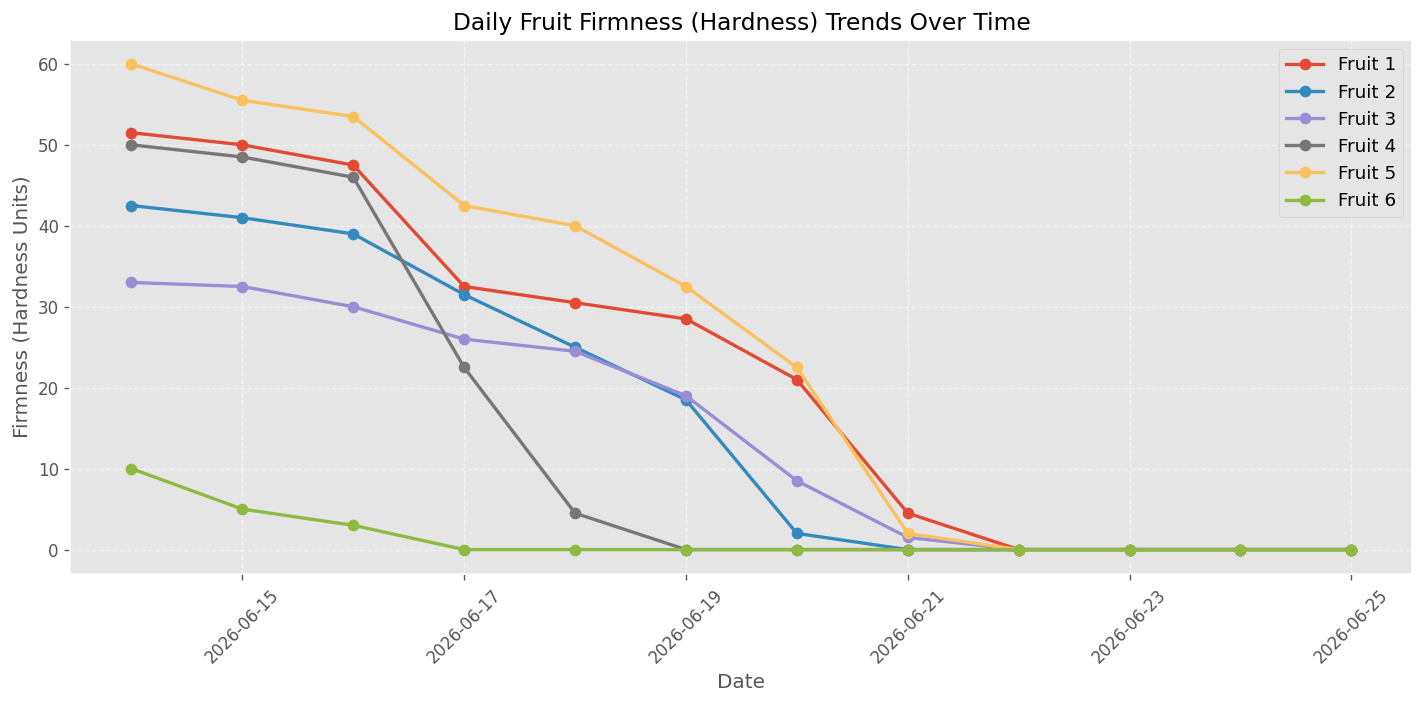

In [ ]:
plt.figure(figsize=(12, 6))
fruit_cols = [c for c in df_hardness.columns if c.startswith('fruit_')]

# Parse hardness time
df_hardness_sorted = df_hardness.copy()
df_hardness_sorted['datetime'] = pd.to_datetime(df_hardness_sorted['time'])
df_hardness_sorted = df_hardness_sorted.sort_values('datetime')

for col in fruit_cols:
    plt.plot(df_hardness_sorted['datetime'], df_hardness_sorted[col], marker='o', linewidth=2, label=col.replace('_', ' ').title())

plt.title('Daily Fruit Firmness (Hardness) Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Firmness (Hardness Units)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

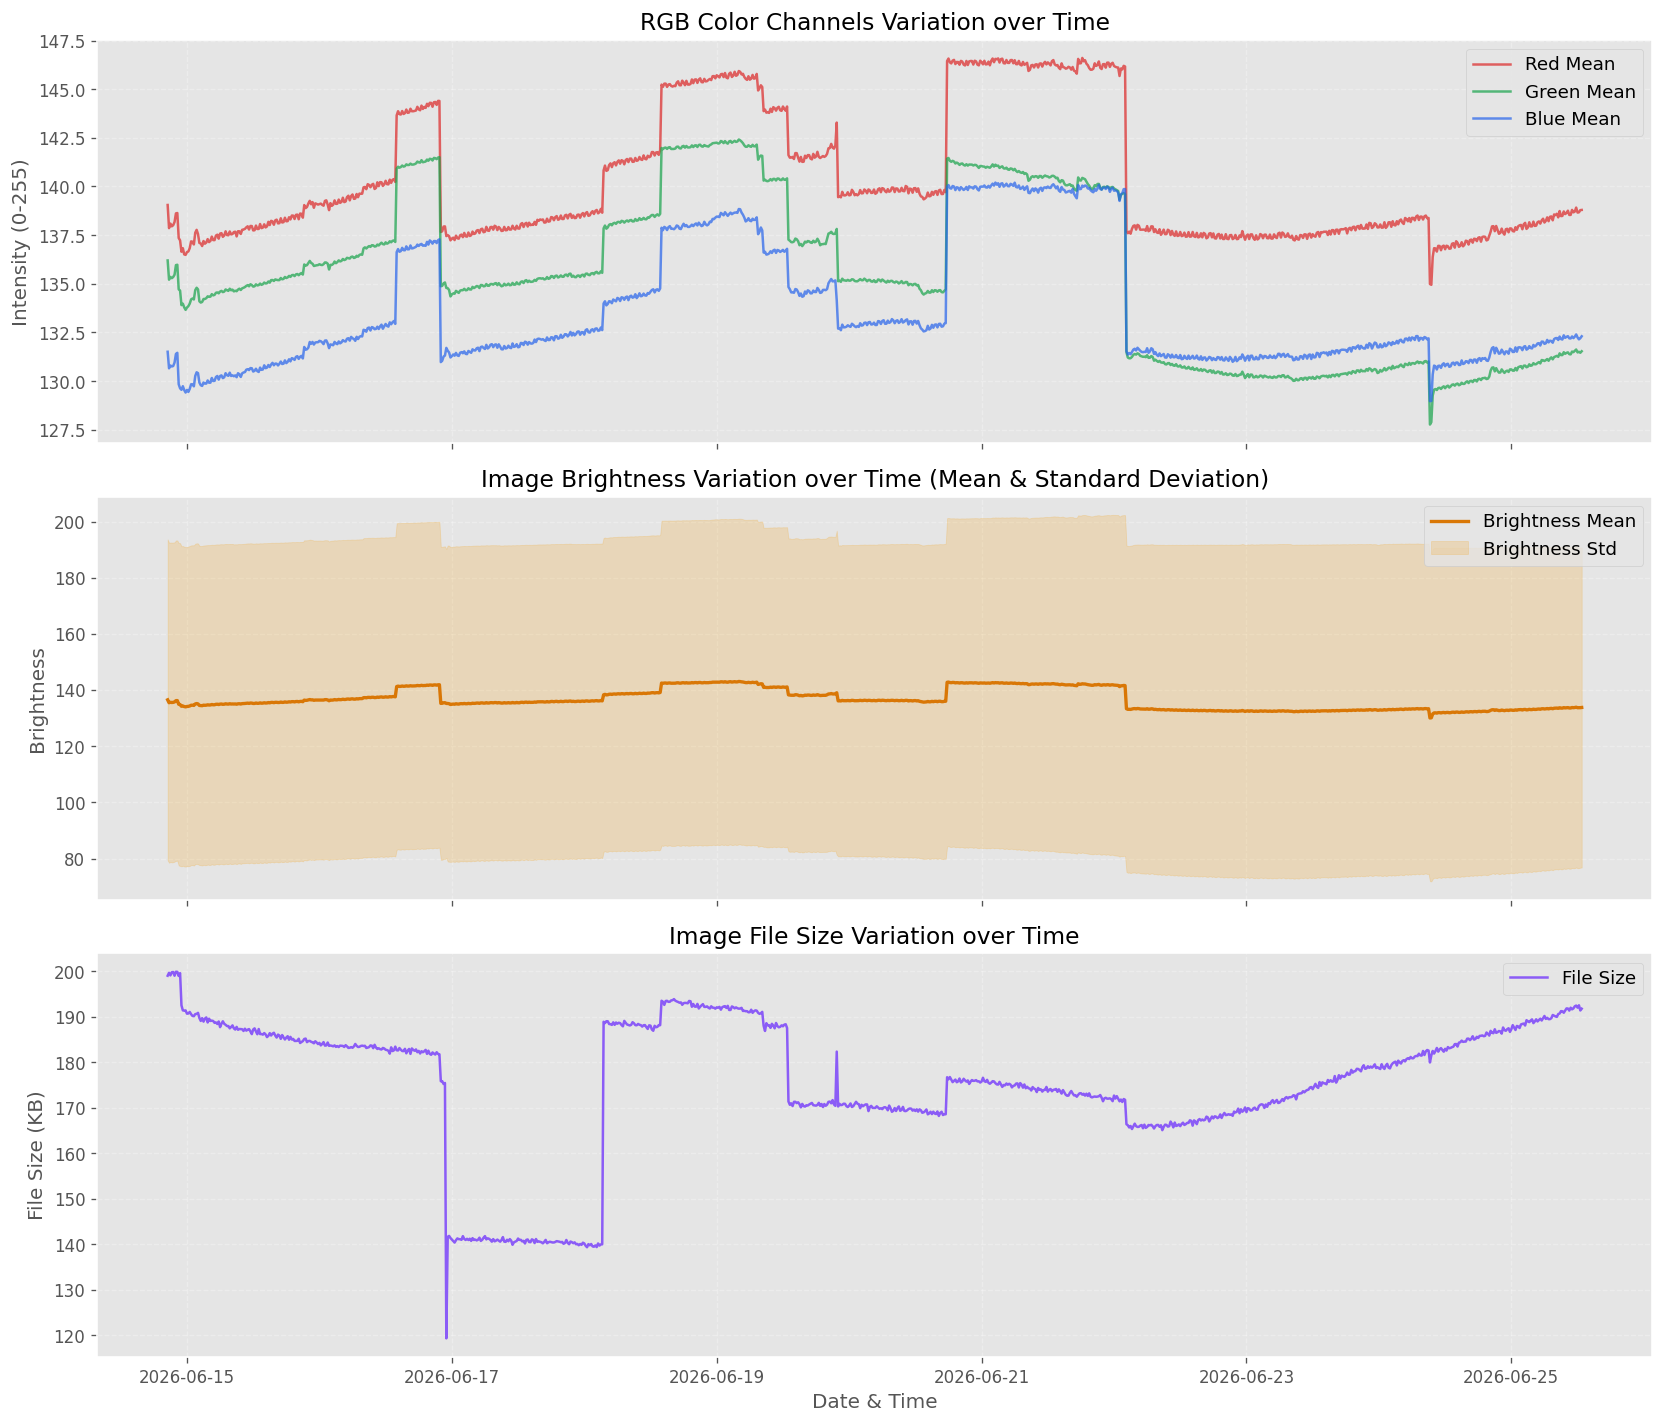

In [ ]:
# Sort master image dataframe by timestamp
df_master_sorted = df_master_parsed.sort_values('datetime')

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Color Channel Mean Variation
axes[0].plot(df_master_sorted['datetime'], df_master_sorted['mean_r'], color='#dc2626', label='Red Mean', alpha=0.7)
axes[0].plot(df_master_sorted['datetime'], df_master_sorted['mean_g'], color='#16a34a', label='Green Mean', alpha=0.7)
axes[0].plot(df_master_sorted['datetime'], df_master_sorted['mean_b'], color='#2563eb', label='Blue Mean', alpha=0.7)
axes[0].set_ylabel('Intensity (0-255)')
axes[0].set_title('RGB Color Channels Variation over Time')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2. Brightness Mean & Std
axes[1].plot(df_master_sorted['datetime'], df_master_sorted['brightness_mean'], color='#d97706', label='Brightness Mean', linewidth=2)
axes[1].fill_between(df_master_sorted['datetime'], 
                     df_master_sorted['brightness_mean'] - df_master_sorted['brightness_std'],
                     df_master_sorted['brightness_mean'] + df_master_sorted['brightness_std'],
                     color='#f59e0b', alpha=0.2, label='Brightness Std')
axes[1].set_ylabel('Brightness')
axes[1].set_title('Image Brightness Variation over Time (Mean & Standard Deviation)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.3)

# 3. File Size Variation
axes[2].plot(df_master_sorted['datetime'], df_master_sorted['file_size_bytes'] / 1024, color='#8b5cf6', label='File Size')
axes[2].set_ylabel('File Size (KB)')
axes[2].set_xlabel('Date & Time')
axes[2].set_title('Image File Size Variation over Time')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Summary and Key Findings

1. **Completeness & Destination Findings**:
   - Out of **1,027 discovered files**, **1** file (`mock_id.jpg` in the `hardness` directory) is not part of the active timelapse and has a timestamp parse error. The other **1,026** images correspond exactly to the time period of 2026-06-14 to 2026-06-25.
   - For all **1,026** timestamp-matching images, there is a **100% match** to daily hardness date records and environmental readings.
   - On the numeric side, **all 12 daily hardness records** and **all 1,026 environmental sensor logs** successfully find matching images. The completeness of destinations is **100%**!
   - Gaps: The alignment check shows that the time differences between webcam frames and environmental readings are exactly **0 minutes** (the timestamps match perfectly, showing that the webcam and sensors recorded data synchronously).
   
2. **Temporal Trends**:
   - **Environment**: There are clear diurnal cycles in temperature and humidity, with temperature peaking during the day and humidity dropping, and vice versa at night.
   - **Firmness (Avocado)**: All 6 fruits show a clear decay (softening) over the 12 days. Fruit 6 collapses very quickly (from 10 to near 5 in the first two days), while fruit 5 starts high (60) and steadily decays.
   - **Image Properties**:
     - Brightness and color channel statistics display a strong periodic pattern mirroring the light/dark cycles of the day/night environments.
     - The file sizes also show a diurnal pattern, as image complexity and illumination level affect the JPEG compression efficiency.